# Análise dos resultados da Relaxação Lagrangeana

Resultados em `deterministic-results-lagrangean/` no padrão:
`experiment-preproc-{prep}-heur-{heur}-barrier-{barrier}`

Configurações:
- `use_preprocessing`: 1
- `use_heuristic`: 0 ou 1
- `use_barrier_method`: 0 ou 1

Instâncias determinísticas: `instances/cases-alto-santo`, `instances/cases-limoeiro`

Objetivos:
1. Comparar as 4 configurações (heuristic × barrier)
2. Analisar LB, UB, gap, convergência
3. Melhoria em relação ao ponto de partida (Initial_LB, Initial_UB)
4. Identificar melhor configuração e exportar para LaTeX

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.figsize"] = (10, 6)
matplotlib.rcParams["axes.grid"] = True
matplotlib.rcParams["grid.alpha"] = 0.3

import analysis_utils
import importlib
importlib.reload(analysis_utils)

from analysis_utils import (
    parse_experiment_folder_lagrangean,
    parse_experiment_name_lagrangean,
    export_lagrangean_to_latex,
    export_lagrangean_combined_to_latex,
    instance_sort_key,
    parse_graph_file,
)

BASE_LAGR = Path("deterministic-results-lagrangean")
INSTANCE_FOLDERS_DET = ["instances/cases-alto-santo", "instances/cases-limoeiro"]
if not BASE_LAGR.exists():
    raise FileNotFoundError(f"Pasta {BASE_LAGR} não encontrada.")

In [2]:
# Carregar resultados
raw = parse_experiment_folder_lagrangean(BASE_LAGR)
records = [r for _, r in raw]
df_all = pd.DataFrame(records)

params = [parse_experiment_name_lagrangean(r["experiment"]) for _, r in raw]
if params:
    for k in params[0].keys():
        df_all[k] = [p.get(k) for p in params]

df_all["gap_pct"] = pd.to_numeric(df_all["gap_pct"], errors="coerce")
df_all["config"] = ("heur-" + df_all["use_heuristic"].astype(str)
                     + "-barrier-" + df_all["use_barrier_method"].astype(str))

# Extrair cidade e tamanho
df_all["city"] = df_all["instance_name"].apply(lambda x: "-".join(x.split("-")[:-2]))
df_all["map_size"] = df_all["instance_name"].apply(
    lambda x: int(x.split("-")[-2]) if x.split("-")[-2].isdigit() else 0
)

# Melhoria sobre LB e UB iniciais
df_all["LB_improvement"] = df_all["LB"] - df_all.get("Initial_LB", 0)
df_all["UB_improvement"] = df_all.get("Initial_UB", df_all["UB"]) - df_all["UB"]

print(f"Total de resultados: {len(df_all)}")
print(f"Experimentos: {df_all['experiment'].nunique()}")
print(f"Configurações: {df_all['config'].nunique()}")
df_all.head()

Total de resultados: 156
Experimentos: 4
Configurações: 4


,instance_name,N,M,B,LB,UB,Initial_LB,Initial_UB,Lambda,Max_Iter,...,gap_pct,experiment,use_preprocessing,use_heuristic,use_barrier_method,config,city,map_size,LB_improvement,UB_improvement
0,alto-santo-1000-1,100,304,19,13.0,39.0,0.0,39.0,1.5,5000,...,66.666667,experiment-preproc-1-heur-0-barrier-0,1,0,0,heur-0-barrier-0,alto-santo,1000,13.0,0.0
1,alto-santo-1000-2,127,388,45,43.0,244.0,0.0,246.0,1.5,5000,...,82.377049,experiment-preproc-1-heur-0-barrier-0,1,0,0,heur-0-barrier-0,alto-santo,1000,43.0,2.0
2,alto-santo-1000-3,127,388,45,46.0,251.0,0.0,253.0,1.5,5000,...,81.673307,experiment-preproc-1-heur-0-barrier-0,1,0,0,heur-0-barrier-0,alto-santo,1000,46.0,2.0
3,alto-santo-1000-4,127,388,45,50.0,258.0,0.0,260.0,1.5,5000,...,80.620155,experiment-preproc-1-heur-0-barrier-0,1,0,0,heur-0-barrier-0,alto-santo,1000,50.0,2.0
4,alto-santo-1000-5,127,388,45,61.0,274.0,0.0,277.0,1.5,5000,...,77.737226,experiment-preproc-1-heur-0-barrier-0,1,0,0,heur-0-barrier-0,alto-santo,1000,61.0,3.0


## 1. Comparação entre as 4 configurações

In [3]:
agg = df_all.groupby("config").agg(
    LB_medio=("LB", "mean"),
    UB_medio=("UB", "mean"),
    gap_medio=("gap_pct", "mean"),
    gap_std=("gap_pct", "std"),
    runtime_medio=("Runtime", "mean"),
    LB_improve_medio=("LB_improvement", "mean"),
    UB_improve_medio=("UB_improvement", "mean"),
    n_instances=("instance_name", "nunique"),
).reset_index()
agg = agg.sort_values("gap_medio")
agg

,config,LB_medio,UB_medio,gap_medio,gap_std,runtime_medio,LB_improve_medio,UB_improve_medio,n_instances
3,heur-1-barrier-1,216.769231,244.089482,10.201294,8.408439,13.333333,0.000000,155.577185,39
2,heur-1-barrier-0,216.769231,247.512821,11.191160,9.066616,11.769231,0.000000,152.153846,39
1,heur-0-barrier-1,42.307692,244.089482,81.230777,5.729412,15.461538,42.307692,155.577185,39
0,heur-0-barrier-0,42.358974,247.512821,81.395710,5.783109,13.461538,42.358974,152.153846,39


In [4]:
best_config = agg.iloc[0]["config"]
print(f"Melhor configuração (menor gap médio): {best_config}")
print(agg.iloc[0])

Melhor configuração (menor gap médio): heur-1-barrier-1
config              heur-1-barrier-1
LB_medio                  216.769231
UB_medio                  244.089482
gap_medio                  10.201294
gap_std                     8.408439
runtime_medio              13.333333
LB_improve_medio                 0.0
UB_improve_medio          155.577185
n_instances                       39
Name: 3, dtype: object


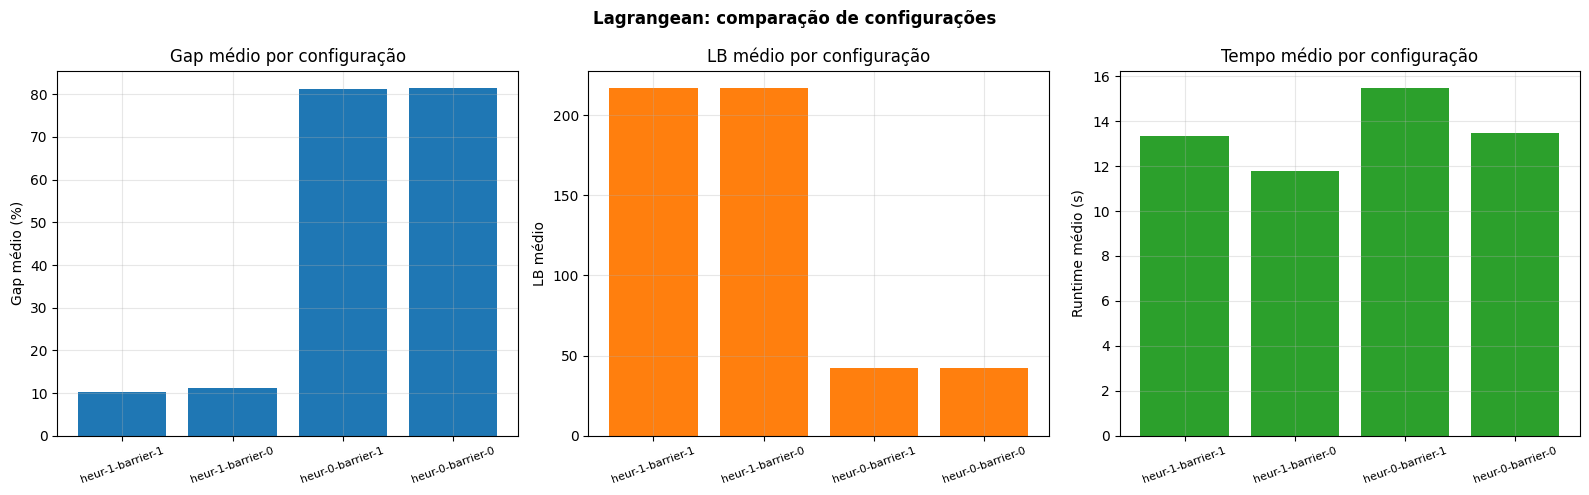

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

configs = agg.sort_values("gap_medio")["config"].values

ax = axes[0]
ax.bar(configs, agg.set_index("config").loc[configs, "gap_medio"], color="C0")
ax.set_ylabel("Gap médio (%)")
ax.set_title("Gap médio por configuração")
ax.tick_params(axis="x", rotation=20, labelsize=8)

ax = axes[1]
ax.bar(configs, agg.set_index("config").loc[configs, "LB_medio"], color="C1")
ax.set_ylabel("LB médio")
ax.set_title("LB médio por configuração")
ax.tick_params(axis="x", rotation=20, labelsize=8)

ax = axes[2]
ax.bar(configs, agg.set_index("config").loc[configs, "runtime_medio"], color="C2")
ax.set_ylabel("Runtime médio (s)")
ax.set_title("Tempo médio por configuração")
ax.tick_params(axis="x", rotation=20, labelsize=8)

plt.suptitle("Lagrangean: comparação de configurações", fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Análise detalhada: LB, UB, gap, convergência

In [6]:
# Tabela por instância para a melhor configuração
df_best = df_all[df_all["config"] == best_config].copy()
df_best = df_best.sort_values("instance_name", key=lambda c: c.map(instance_sort_key))
df_best[["instance_name", "N", "M", "B", "LB", "UB", "gap_pct",
         "Initial_LB", "Initial_UB", "Iterations", "Runtime"]]

,instance_name,N,M,B,LB,UB,gap_pct,Initial_LB,Initial_UB,Iterations,Runtime
117,alto-santo-1000-1,100,304,19,39.0,39.0000,0.000000,39.0,39.0,0,0.0
118,alto-santo-1000-2,127,388,45,238.0,243.6830,2.332128,238.0,246.0,5000,8.0
119,alto-santo-1000-3,127,388,45,245.0,250.6830,2.267007,245.0,253.0,5000,9.0
120,alto-santo-1000-4,127,388,45,252.0,257.6790,2.203905,252.0,260.0,5000,9.0
121,alto-santo-1000-5,127,388,45,268.0,273.6800,2.075417,268.0,277.0,5000,9.0
122,alto-santo-1000-6,130,400,49,319.0,328.0900,2.770581,319.0,338.0,5000,10.0
123,alto-santo-2000-1,100,304,19,39.0,39.0000,0.000000,39.0,39.0,0,0.0
124,alto-santo-2000-2,159,480,47,247.0,252.4240,2.148766,247.0,268.0,5000,10.0
125,alto-santo-2000-3,159,480,47,251.0,258.9240,3.060357,251.0,275.0,5000,9.0
126,alto-santo-2000-4,159,480,47,258.0,265.9240,2.979799,258.0,282.0,5000,9.0


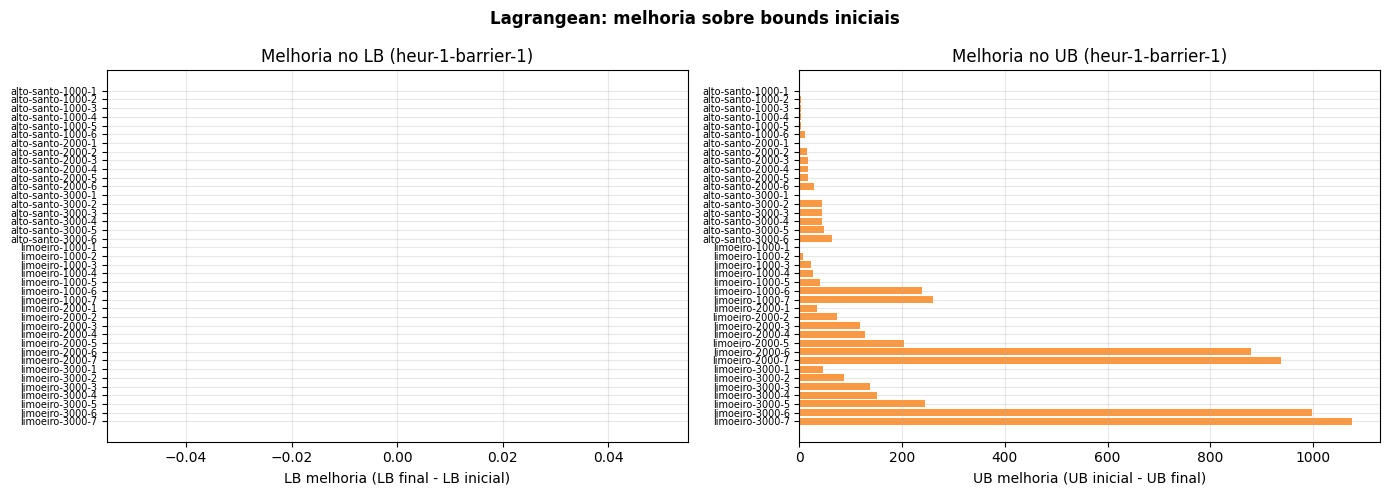

In [7]:
# Melhoria: LB final vs Initial_LB, UB final vs Initial_UB
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.barh(df_best["instance_name"], df_best["LB_improvement"], color="C0", alpha=0.8)
ax.set_xlabel("LB melhoria (LB final - LB inicial)")
ax.set_title(f"Melhoria no LB ({best_config})")
ax.invert_yaxis()
ax.tick_params(axis="y", labelsize=7)

ax = axes[1]
ax.barh(df_best["instance_name"], df_best["UB_improvement"], color="C1", alpha=0.8)
ax.set_xlabel("UB melhoria (UB inicial - UB final)")
ax.set_title(f"Melhoria no UB ({best_config})")
ax.invert_yaxis()
ax.tick_params(axis="y", labelsize=7)

plt.suptitle("Lagrangean: melhoria sobre bounds iniciais", fontweight="bold")
plt.tight_layout()
plt.show()

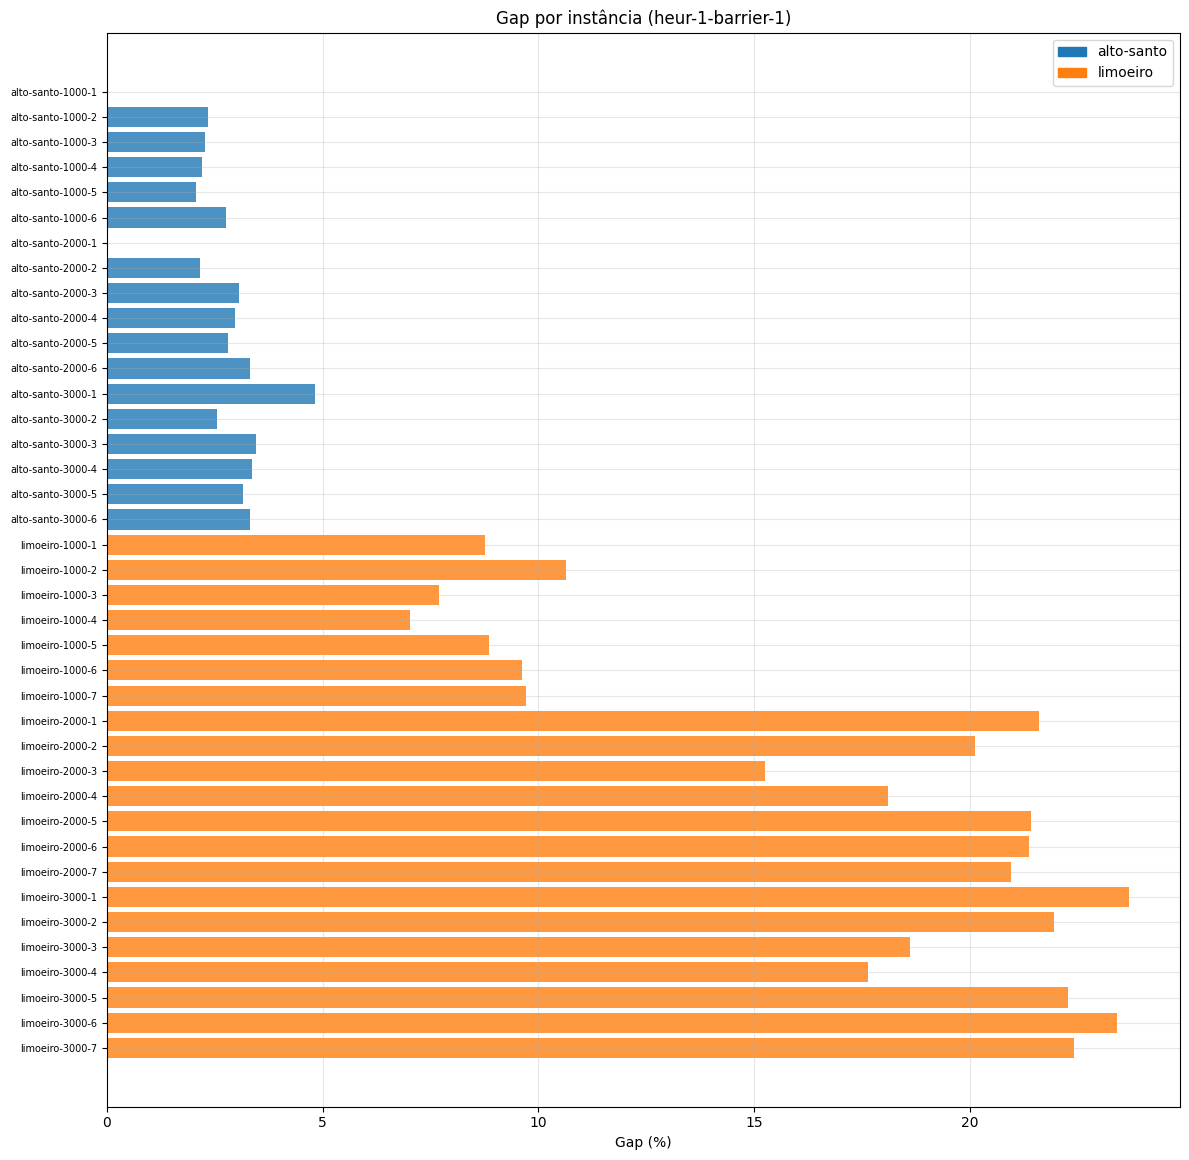

In [8]:
# Gap por instância (melhor config)
fig, ax = plt.subplots(figsize=(12, max(6, len(df_best) * 0.3)))
colors = ["C0" if city == "alto-santo" else "C1" for city in df_best["city"]]
ax.barh(df_best["instance_name"], df_best["gap_pct"], color=colors, alpha=0.8)
ax.set_xlabel("Gap (%)")
ax.set_title(f"Gap por instância ({best_config})")
ax.invert_yaxis()
ax.tick_params(axis="y", labelsize=7)
# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="C0", label="alto-santo"), Patch(color="C1", label="limoeiro")])
plt.tight_layout()
plt.show()

## 3. Comparação por cidade e tamanho do mapa

In [9]:
agg_city = df_best.groupby(["city", "map_size"]).agg(
    LB_medio=("LB", "mean"),
    UB_medio=("UB", "mean"),
    gap_medio=("gap_pct", "mean"),
    runtime_medio=("Runtime", "mean"),
    n=("instance_name", "count"),
).reset_index()
agg_city

,city,map_size,LB_medio,UB_medio,gap_medio,runtime_medio,n
0,alto-santo,1000,226.833333,232.135833,1.941506,7.500000,6
1,alto-santo,2000,232.333333,239.050333,2.383975,7.666667,6
2,alto-santo,3000,231.666667,239.386867,3.441603,9.166667,6
3,limoeiro,1000,182.142857,200.621329,8.904065,10.571429,7
4,limoeiro,2000,217.857143,273.745429,19.840027,20.428571,7
5,limoeiro,3000,215.571429,276.497757,21.434186,22.428571,7


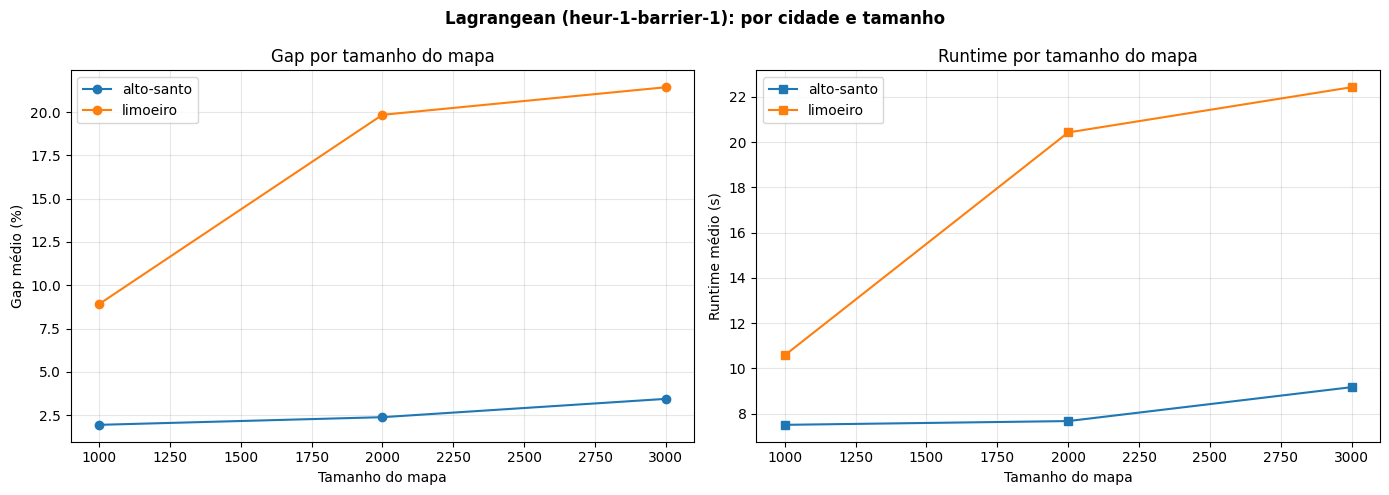

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for city in df_best["city"].unique():
    sub = agg_city[agg_city["city"] == city].sort_values("map_size")
    axes[0].plot(sub["map_size"], sub["gap_medio"], "o-", label=city)
    axes[1].plot(sub["map_size"], sub["runtime_medio"], "s-", label=city)

axes[0].set_xlabel("Tamanho do mapa")
axes[0].set_ylabel("Gap médio (%)")
axes[0].set_title("Gap por tamanho do mapa")
axes[0].legend()
axes[1].set_xlabel("Tamanho do mapa")
axes[1].set_ylabel("Runtime médio (s)")
axes[1].set_title("Runtime por tamanho do mapa")
axes[1].legend()
plt.suptitle(f"Lagrangean ({best_config}): por cidade e tamanho", fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Exportação LaTeX (cada configuração)

In [11]:
OUT_LATEX = Path("latex-tables-lagrangean")
OUT_LATEX.mkdir(parents=True, exist_ok=True)

for exp_name in sorted(df_all["experiment"].unique()):
    df_exp = df_all[df_all["experiment"] == exp_name].copy()
    df_exp = df_exp.sort_values("instance_name", key=lambda c: c.map(instance_sort_key))

    p = parse_experiment_name_lagrangean(exp_name)
    prep = p.get("use_preprocessing", "?")
    heur = p.get("use_heuristic", "?")
    barrier = p.get("use_barrier_method", "?")
    caption = f"Results of Lagrangean Relaxation (prep={prep}, heuristic={heur}, barrier={barrier})."
    label = f"tab:lagr-p{prep}-h{heur}-b{barrier}"
    latex = export_lagrangean_to_latex(df_exp, caption=caption, label=label)
    fname = f"table-{exp_name}.tex"
    (OUT_LATEX / fname).write_text(latex, encoding="utf-8")
    print(f"Exportado: {OUT_LATEX / fname}")

print(f"\nTotal de tabelas: {len(list(OUT_LATEX.glob('*.tex')))}")
# Preview da melhor
best_exp = df_all[df_all["config"] == best_config]["experiment"].iloc[0]
print(f"\n--- Prévia ({best_exp}) ---")
print((OUT_LATEX / f"table-{best_exp}.tex").read_text()[:800])

Exportado: latex-tables-lagrangean/table-experiment-preproc-1-heur-0-barrier-0.tex
Exportado: latex-tables-lagrangean/table-experiment-preproc-1-heur-0-barrier-1.tex
Exportado: latex-tables-lagrangean/table-experiment-preproc-1-heur-1-barrier-0.tex
Exportado: latex-tables-lagrangean/table-experiment-preproc-1-heur-1-barrier-1.tex

Total de tabelas: 4

--- Prévia (experiment-preproc-1-heur-1-barrier-1) ---
\begin{table}[ht!]
\centering
\caption{Results of Lagrangean Relaxation (prep=1, heuristic=1, barrier=1).}
\label{tab:lagr-p1-h1-b1}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lrrrrrrrr}
\toprule
\multicolumn{1}{c}{\textbf{Instance}} & \multicolumn{1}{c}{\textbf{|V|}} & \multicolumn{1}{c}{\textbf{|A|}} & \multicolumn{1}{c}{\textbf{|B|}} & \multicolumn{1}{c}{\textbf{LB}} & \multicolumn{1}{c}{\textbf{UB}} & \multicolumn{1}{c}{\textbf{gap (\%)}} & \multicolumn{1}{c}{\textbf{Iterations}} & \multicolumn{1}{c}{\textbf{\begin{tabular}[c]{@{}c@{}}Exec.\\ Time (s)\end{tabular}}} \\
\midrule
\

## 5. Exportação LaTeX combinada (4 configurações lado a lado)

In [12]:
import importlib
import analysis_utils
importlib.reload(analysis_utils)
from analysis_utils import export_lagrangean_combined_to_latex

config_order = [
    "experiment-preproc-1-heur-0-barrier-0",
    "experiment-preproc-1-heur-1-barrier-0",
    "experiment-preproc-1-heur-0-barrier-1",
    "experiment-preproc-1-heur-1-barrier-1",
]
config_labels = [
    "LR-RCSP-KN-Prep",
    "LR-RCSP-KN-HR-Prep",
    "LR-RCSP-KN-BM-Prep",
    "LR-RCSP-KN-HR-BM-Prep",
]

latex_combined = export_lagrangean_combined_to_latex(
    df_all,
    config_order=config_order,
    config_labels=config_labels,
    caption="Results of Lagrangean Relaxations With Preprocessing.",
    label="tab:results-lagrange-relax-preprocessing",
)

out_path = Path("latex-tables-lagrangean") / "table-combined-preprocessing.tex"
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(latex_combined, encoding="utf-8")
print(f"Exportado: {out_path}")
print()
print(latex_combined)

Exportado: latex-tables-lagrangean/table-combined-preprocessing.tex

\begin{table}[ht!]
\centering
\caption{Results of Lagrangean Relaxations With Preprocessing.}
\label{tab:results-lagrange-relax-preprocessing}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lrrr|rrrrrr|rrrrrr|rrrrrr|rrrrrr}
\toprule
\multicolumn{1}{c}{} &
\multicolumn{1}{c}{} &
\multicolumn{1}{c}{} &
\multicolumn{1}{c}{} &
\multicolumn{6}{c|}{\textbf{LR-RCSP-KN-Prep}} &
\multicolumn{6}{c|}{\textbf{LR-RCSP-KN-HR-Prep}} &
\multicolumn{6}{c|}{\textbf{LR-RCSP-KN-BM-Prep}} &
\multicolumn{6}{c}{\textbf{LR-RCSP-KN-HR-BM-Prep}} \\
\cmidrule(lr){5-10}\cmidrule(lr){11-16}\cmidrule(lr){17-22}\cmidrule(lr){23-28}
\multicolumn{1}{c}{\textbf{Instance}} &
\multicolumn{1}{c}{\textbf{|V|}} &
\multicolumn{1}{c}{\textbf{|A|}} &
\multicolumn{1}{c|}{\textbf{|B|}} &
\multicolumn{1}{c}{\textbf{\begin{tabular}[c]{@{}c@{}}Initial\\ LB\end{tabular}}} &
\multicolumn{1}{c}{\textbf{LB}} &
\multicolumn{1}{c}{\textbf{\begin{tabular}[c]{@{}c@{}}Initial